In [6]:
import numpy as np
import matplotlib.pyplot as plt


# SDE - OU process and Euler Maruyama method

In [7]:
from matplotlib.gridspec import GridSpec

def m_t(t, mu1, beta):
    """time t mu"""
    return np.exp(-beta*t) * mu1

def v_t(t, s1, beta, sigma):
    """time t var"""
    return np.exp(-2*beta*t) * s1**2 + (sigma**2/(2*beta)) * (1.0 - np.exp(-2*beta*t))

def gmm_ou_pdf(y, t, mu1, s1, beta, sigma):
    """time t  PDF """
    y = np.asarray(y)
    m = m_t(t, mu1, beta)
    v = v_t(t, s1, beta, sigma)
    return (1.0 / np.sqrt(2*np.pi * v)) * np.exp(-0.5 * (y - m)**2 / v)

def gmm_ou_score(x, t, mu1, s1, beta, sigma):
    """Score function: ∇_x log p_t(x)"""
    m = m_t(t, mu1, beta)
    v = v_t(t, s1, beta, sigma)
    return -(x - m) / v



**Initialization:**
Sample the starting data point from $p_0(x)$:
$$x_0 \sim \mathcal{N}(\mu_1, s_1^2)$$

**Iteration:**
For $k = 0, 1, \cdots, K-1$:

$$
\begin{aligned}
& \text{Update step (Deterministic):} \\
& x_{k+1} = x_k + \Delta t \left( -\beta x_k - \frac{1}{2}\sigma^2 \nabla \log p(x_k, k\Delta t) \right)
\end{aligned}
$$

In [8]:
def run_sde_forward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part):
    steps = int(T/dt)
    # 初始採樣 x0 ~ N(5,1)
    x = rng.normal(mu1, s1, size=N_part)
    
    times = [0.0]
    traj_hist = [x[:K_traj].copy()]
    t = 0.0
    
    for i in range(1, steps+1):
        dW = rng.normal(0.0, np.sqrt(dt), size=N_part)
        x = x + (-beta*x)*dt + sigma*dW      # Forward SDE
        t += dt
        
        if i % max(1, int(steps/300)) == 0:
            times.append(t)
            traj_hist.append(x[:K_traj].copy())

    return np.array(times), np.stack(traj_hist, axis=0) 

**Initialization:**
Set $K = T/\Delta t$, and sample from the approximate steady state:
$$\bar{x}_K \sim \mathcal{N}(0, \sigma_T^2)$$

**Iteration:**
For $k = K, K-1, \cdots, 1$:

$$
\begin{aligned}
& \text{Update step (Deterministic):} \\
& \bar{x}_{k-1} = \bar{x}_k - \Delta t \left( -\beta \bar{x}_k - \frac{1}{2}\sigma^2 \nabla \log p(\bar{x}_k, k\Delta t) \right)
\end{aligned}
$$

In [9]:
def run_sde_backward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part):
    steps = int(T/dt)
    
    # 初始採樣 xT ~ pT (理論穩態)
    mean_T = m_t(T, mu1, beta)
    var_T  = v_t(T, s1, beta, sigma)
    x = rng.normal(mean_T, np.sqrt(var_T), size=N_part)
    
    times = [T]
    traj_hist = [x[:K_traj].copy()]
    t = T
    
    for i in range(1, steps+1):
        dW = rng.normal(0.0, np.sqrt(dt), size=N_part)
        score = gmm_ou_score(x, t, mu1, s1, beta, sigma)
        
        # Backward SDE drift
        drift = -beta*x - (sigma**2) * score  ##<<
        
        # dt<0
        x = x + drift * (-dt) + sigma * dW    ##<< Euler maruyama
        t -= dt
        
        if i % max(1, int(steps/300)) == 0:
            times.append(t)
            traj_hist.append(x[:K_traj].copy())
            
    times = np.array(times)
    traj_hist = np.stack(traj_hist, axis=0)
    
    return times, traj_hist



In [ ]:
def plot_overlay_with_densities(times_fwd, traj_fwd, times_rev, traj_rev, 
                                mu1, s1, beta, sigma, T):
    
    fig = plt.figure(figsize=(14, 6))
    
    # 定義佈局：左(PDF) - 中(軌跡) - 右(PDF)
    gs = GridSpec(nrows=1, ncols=3, width_ratios=[1, 6, 1], wspace=0.05)
    
    ax_left  = fig.add_subplot(gs[0])
    ax_main  = fig.add_subplot(gs[1])
    ax_right = fig.add_subplot(gs[2])
    
    # --- 1. 設定 Y 軸範圍 (確保三張圖一致) ---
    ylims = (-4,10)   
    ys = np.linspace(ylims[0], ylims[1], 500)
    
    # --- 2. 左側面板 (t=0 PDF) ---
    # 計算 p_0(x)
    pdf_0 = gmm_ou_pdf(ys, 0.0, mu1, s1, beta, sigma)
    
    ax_left.plot(pdf_0, ys, color="black", linewidth=2, label="$p_0(x)$")
    ax_left.fill_betweenx(ys, 0, pdf_0, color="blue", alpha=0.2) # 填充顏色代表數據端
    
    ax_left.set_ylim(ylims)
    ax_left.set_xlabel("Density")
    ax_left.set_title(r"$t=0$ (Data)", fontsize=12)
    ax_left.invert_xaxis() # 翻轉 x 軸讓背對背比較好看 (選用)
    ax_left.spines['top'].set_visible(False)
    ax_left.spines['left'].set_visible(False)
    # ax_left.set_xticks([]) # 隱藏刻度看個人喜好
    
    # --- 3. 右側面板 (t=T PDF) ---
    # 計算 p_T(x)
    pdf_T = gmm_ou_pdf(ys, T, mu1, s1, beta, sigma)
    
    ax_right.plot(pdf_T, ys, color="black", linewidth=2, label="$p_T(x)$")
    ax_right.fill_betweenx(ys, 0, pdf_T, color="orange", alpha=0.2) 
    
    ax_right.set_ylim(ylims)
    ax_right.set_xlabel("Density")
    ax_right.set_title(r"$t=T$ (Noise)", fontsize=12)
    ax_right.set_yticks([]) 
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    
    # --- 4. 中間面板 (軌跡疊加) ---
    # 畫 Forward (Blue)
    for k in range(traj_fwd.shape[1]):
        label = "Forward SDE" if k == 0 else None
        ax_main.plot(times_fwd, traj_fwd[:, k], color='blue', alpha=0.15, linewidth=1, label=label)
        
    # 畫 Backward (Orange)
    for k in range(traj_rev.shape[1]):
        label = "Backward SDE" if k == 0 else None
        ax_main.plot(times_rev, traj_rev[:, k], color='orange', alpha=0.25, linewidth=1, label=label)
        
    ax_main.set_ylim(ylims)
    ax_main.set_xlim(0, T)
    ax_main.set_xlabel("Time $t$")
    ax_main.set_title("Overlay of Forward (Blue) and Backward (Orange) Processes")
    ax_main.set_yticks([]) # 隱藏 Y 軸標籤，保持乾淨
    
    # 加個 Legend (只顯示一次標籤)
    handles = [
        plt.Line2D([], [], color='blue', alpha=0.5, label='Forward (Data $\\to$ Noise)'),
        plt.Line2D([], [], color='orange', alpha=0.5, label='Backward (Noise $\\to$ Data)')
    ]
    ax_main.legend(handles=handles, loc='upper right')
    
    plt.tight_layout()
    plt.show()


Running Forward SDE...
Running Backward SDE...
Plotting...


C:\Users\user\AppData\Local\Temp\ipykernel_13876\4240067458.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


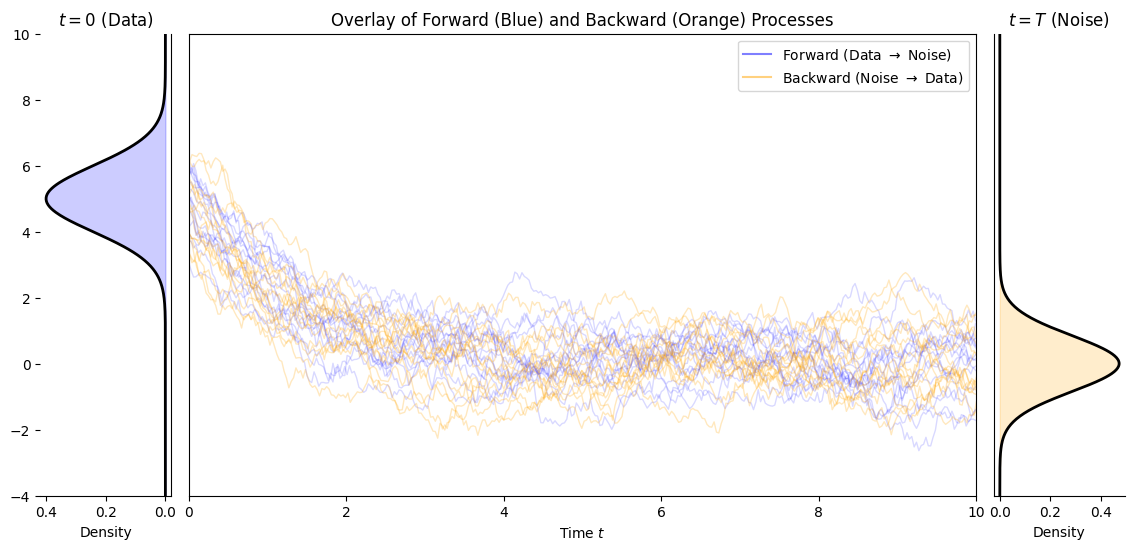

In [11]:
# 參數設定
beta = 0.7
sigma = 1.0
T = 10.0      # 縮短一點 T 讓圖形緊湊些
dt = 0.01
mu1 = 5.0     # 初始均值
s1 = 1.0      # 初始標準差
K_traj = 15   # 畫多少條線
N_part = 1000 # 粒子數

rng = np.random.default_rng(42)

# Main Simulation
print("Running Forward SDE...")
times_f, traj_f = run_sde_forward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part)

print("Running Backward SDE...")
times_b, traj_b = run_sde_backward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part)

# 畫圖
print("Plotting...")
plot_overlay_with_densities(times_f, traj_f, times_b, traj_b, mu1, s1, beta, sigma, T)

---

# ODE

C:\Users\user\AppData\Local\Temp\ipykernel_28400\557349449.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


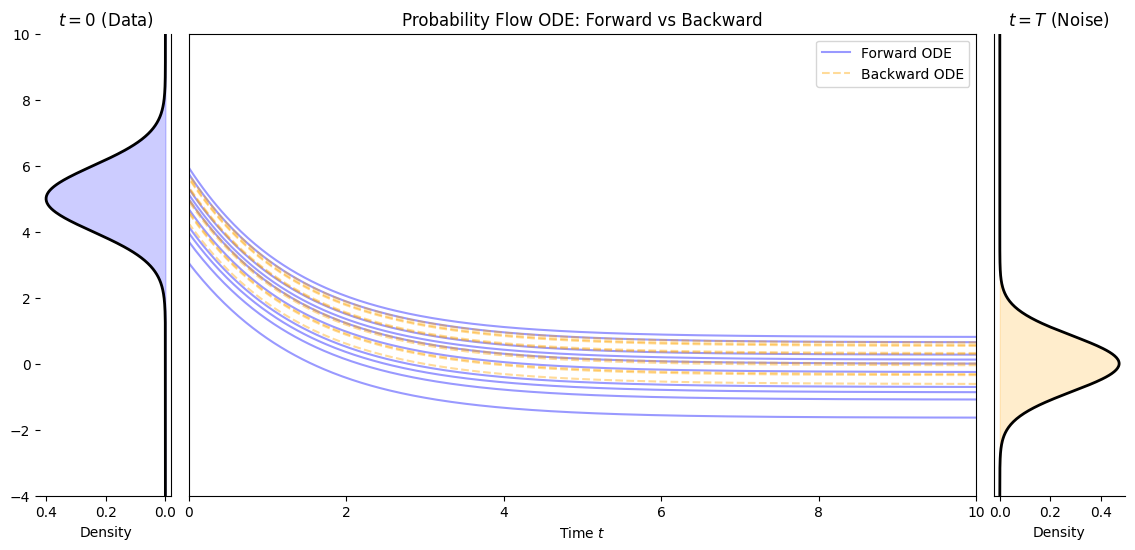

In [ ]:
def run_ode_forward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part):
    steps = int(T/dt)
    
    # 初始: x ~ p0
    x = rng.normal(mu1, s1, size=N_part)
    
    times = [0.0]
    traj_hist = [x[:K_traj].copy()]
    t = 0.0
    
    for i in range(1, steps+1):
        t += dt 
        
        # 計算 Score
        score = gmm_ou_score(x, t, mu1, s1, beta, sigma)
        
        # Probability flow ODE drift: f(x) - 0.5 * g(t)^2 * score
        # f(x) = -beta * x
        drift = -beta * x - 0.5 * (sigma**2) * score
        
        # Euler update (無隨機項)
        x = x + drift * dt
        
        if i % max(1, int(steps/300)) == 0:
            times.append(t)
            traj_hist.append(x[:K_traj].copy())
            
    return np.array(times), np.stack(traj_hist, axis=0)

def run_ode_backward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part):
    steps = int(T/dt)
    
    # 初始: x ~ pT (理論近似)
    mean_T = m_t(T, mu1, beta)
    var_T  = v_t(T, s1, beta, sigma)
    x = rng.normal(mean_T, np.sqrt(var_T), size=N_part)
    
    times = [T]
    traj_hist = [x[:K_traj].copy()]
    t = T
    
    for i in range(1, steps+1):
        # 計算 Score
        score = gmm_ou_score(x, t, mu1, s1, beta, sigma)
        
        # Backward ODE drift (形式與 Forward 相同，只是積分方向相反)
        drift = -beta * x - 0.5 * (sigma**2) * score
        
        # Backward Euler: dt 為負
        x = x + drift * (-dt)
        t -= dt
        
        if i % max(1, int(steps/300)) == 0:
            times.append(t)
            traj_hist.append(x[:K_traj].copy())
            
    return np.array(times), np.stack(traj_hist, axis=0)

# ==========================================
# 3. 繪圖函數
# ==========================================
def plot_ode_overlay(times_fwd, traj_fwd, times_rev, traj_rev, 
                     mu1, s1, beta, sigma, T):
    
    fig = plt.figure(figsize=(14, 6))
    gs = GridSpec(nrows=1, ncols=3, width_ratios=[1, 6, 1], wspace=0.05)
    
    ax_left  = fig.add_subplot(gs[0])
    ax_main  = fig.add_subplot(gs[1])
    ax_right = fig.add_subplot(gs[2])
    
    # Y軸範圍設定
    ylims = (-4, 10)
    ys = np.linspace(ylims[0], ylims[1], 500)
    
    # 左圖: p0
    pdf_0 = gmm_ou_pdf(ys, 0.0, mu1, s1, beta, sigma)
    ax_left.plot(pdf_0, ys, color="black", linewidth=2)
    ax_left.fill_betweenx(ys, 0, pdf_0, color="blue", alpha=0.2)
    ax_left.set_ylim(ylims)
    ax_left.set_title(r"$t=0$ (Data)")
    ax_left.invert_xaxis()
    ax_left.spines['top'].set_visible(False)
    ax_left.spines['left'].set_visible(False)
    ax_left.set_xlabel("Density")

    # 右圖: pT
    pdf_T = gmm_ou_pdf(ys, T, mu1, s1, beta, sigma)
    ax_right.plot(pdf_T, ys, color="black", linewidth=2)
    ax_right.fill_betweenx(ys, 0, pdf_T, color="orange", alpha=0.2)
    ax_right.set_ylim(ylims)
    ax_right.set_title(r"$t=T$ (Noise)")
    ax_right.set_yticks([])
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)
    ax_right.set_xlabel("Density")

    # 中間: 軌跡
    # Forward ODE (Blue)
    for k in range(traj_fwd.shape[1]):
        l = "Forward ODE" if k==0 else None
        ax_main.plot(times_fwd, traj_fwd[:, k], color='blue', alpha=0.4, linewidth=1.5, label=l)
        
    # Backward ODE (Orange)
    for k in range(traj_rev.shape[1]):
        l = "Backward ODE" if k==0 else None
        ax_main.plot(times_rev, traj_rev[:, k], color='orange', alpha=0.4, linewidth=1.5, label=l, linestyle='--')
        
    ax_main.set_ylim(ylims)
    ax_main.set_xlim(0, T)
    ax_main.set_xlabel("Time $t$")
    ax_main.set_title("Probability Flow ODE: Forward vs Backward")
    ax_main.set_yticks([])
    ax_main.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 執行
# ==========================================
beta = 0.7
sigma = 1.0
T = 10.0
dt = 0.01
mu1 = 5.0
s1 = 1.0
K_traj = 10
N_part = 1000

rng = np.random.default_rng(42)

times_f, traj_f = run_ode_forward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part)
times_b, traj_b = run_ode_backward(beta, sigma, rng, T, dt, mu1, s1, K_traj, N_part)

plot_ode_overlay(times_f, traj_f, times_b, traj_b, mu1, s1, beta, sigma, T)